In [ ]:
!pip install tensorflow
!pip install tensorflow-io
!pip install matplotlib
!pip install kagglehub -q

import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [ ]:
path = kagglehub.dataset_download(
    "kenjee/z-by-hp-unlocked-challenge-3-signal-processing"
)

print("Dataset path:", path)
print("Folders:", os.listdir(path))


Using Colab cache for faster access to the 'z-by-hp-unlocked-challenge-3-signal-processing' dataset.
Dataset path: /kaggle/input/z-by-hp-unlocked-challenge-3-signal-processing
Folders: ['Parsed_Not_Capuchinbird_Clips', 'Forest Recordings', 'Parsed_Capuchinbird_Clips']


In [ ]:
CAPUCHIN_PATH = os.path.join(path,
                             "Parsed_Capuchinbird_Clips")
NOT_PATH = os.path.join(path,
                        "Parsed_Not_Capuchinbird_Clips")

pos_files = tf.data.Dataset.list_files(
    CAPUCHIN_PATH + "/*.wav"
)

neg_files = tf.data.Dataset.list_files(
    NOT_PATH + "/*.wav"
)

pos_ds = pos_files.map(lambda x: (x, 1))
neg_ds = neg_files.map(lambda x: (x, 0))

dataset = pos_ds.concatenate(neg_ds)

In [ ]:
def preprocess(file_path, label):
    audio_binary = tf.io.read_file(file_path)
    waveform, sample_rate = tf.audio.decode_wav(
        audio_binary,
        desired_channels=1
    )

    waveform = tf.squeeze(waveform, axis=-1)

    # Standardize to 3 seconds (48000 samples)
    waveform = waveform[:48000]

    zero_padding = tf.zeros(
        [48000] - tf.shape(waveform),
        dtype=tf.float32
    )

    waveform = tf.concat([waveform, zero_padding], 0)

    # Spectrogram conversion
    spectrogram = tf.signal.stft(
        waveform,
        frame_length=320,
        frame_step=32
    )

    spectrogram = tf.abs(spectrogram)

    # Add channel dimension
    spectrogram = spectrogram[..., tf.newaxis]

    return spectrogram, label

In [ ]:
dataset = dataset.map(preprocess)

dataset = dataset.shuffle(1000)

dataset = dataset.cache()

dataset_size = tf.data.experimental.cardinality(dataset).numpy()
train_size = int(0.8 * dataset_size)

train_ds = dataset.take(train_size).batch(16)
val_ds = dataset.skip(train_size).batch(16)

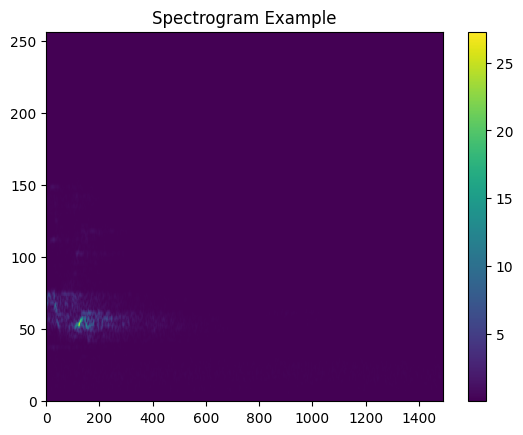

In [ ]:
for spec, label in train_ds.take(1):

    image = spec[0]          # remove batch
    image = tf.squeeze(image)  # remove channel dimension

    plt.imshow(image.numpy().T,
               aspect='auto',
               origin='lower')

    plt.title("Spectrogram Example")
    plt.colorbar()
    plt.show()

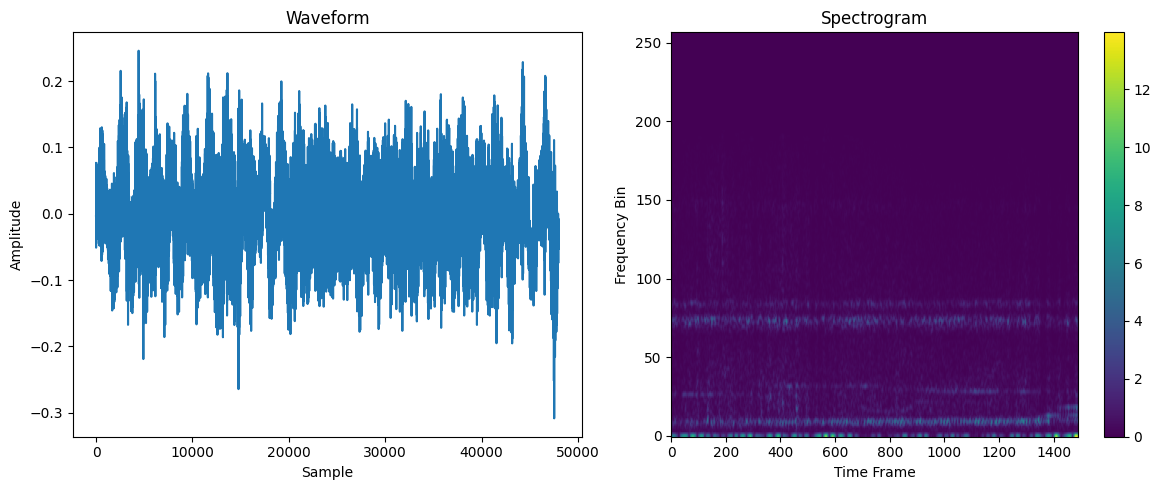

In [ ]:
# import matplotlib.pyplot as plt

# for wave, spec, label in train_ds.take(1):

#     wave = wave[0]               # remove batch
#     spec = spec[0]               # remove batch
#     spec = tf.squeeze(spec)      # remove channel

#     plt.figure(figsize=(12,5))

#     # Waveform
#     plt.subplot(1,2,1)
#     plt.plot(wave)
#     plt.title("Waveform")
#     plt.xlabel("Sample")
#     plt.ylabel("Amplitude")

#     # Spectrogram
#     plt.subplot(1,2,2)
#     plt.imshow(tf.transpose(spec),
#                aspect='auto',
#                origin='lower')
#     plt.title("Spectrogram")
#     plt.xlabel("Time Frame")
#     plt.ylabel("Frequency Bin")
#     plt.colorbar()

#     plt.tight_layout()
#     plt.show()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1,
                          activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
41/41 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.7244 - loss: 0.6729 - val_accuracy: 0.7654 - val_loss: 0.5963
Epoch 2/3
41/41 ━━━━━━━━━━━━━━━━━━━━ 191s 5s/step - accuracy: 0.7394 - loss: 0.6057 - val_accuracy: 0.7654 - val_loss: 0.5680
Epoch 3/3
41/41 ━━━━━━━━━━━━━━━━━━━━ 189s 4s/step - accuracy: 0.7394 - loss: 0.5823 - val_accuracy: 0.7654 - val_loss: 0.5429


In [ ]:
print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

Final Validation Accuracy: 0.7654321193695068
